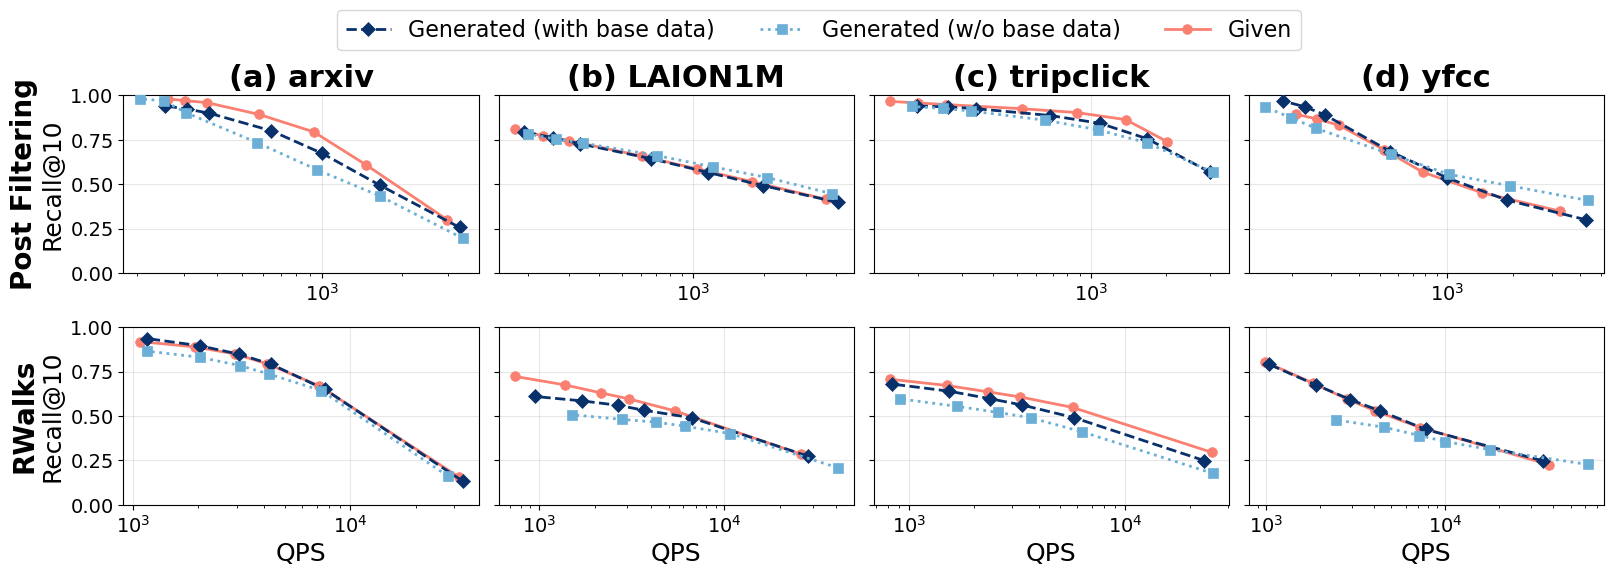

[Saved] fidelity_search_modi.pdf


In [9]:
import pickle
import os
import matplotlib.pyplot as plt

# =================================================
# 0) 옵션: 마커 모양/크기/선굵기/폰트
# =================================================
MARKER_STYLE = "D"   # 예: "o", "s", "D", "^", "x", "*"
MARKER_SIZE = 7
MARKER_EDGE_WIDTH = 0.5

LINE_WIDTH   = 2

FS_SUPTITLE  = 20
FS_TITLE     = 22
FS_LABEL     = 22
FS_TICK      = 16
FS_LEGEND    = 20

# =================================================
# 1) 데이터 로딩
# =================================================
pf_path = os.path.join(".", "Post_Filtering_trade_off_all.pkl")

with open(pf_path, "rb") as f:
    trade_off_pf = pickle.load(f)


# --- Row 2: RWalks
rwalks_path = os.path.join(".", "RWalks_trade_off_result_all.pkl")
with open(rwalks_path, "rb") as f:
    trade_off_rwalks = pickle.load(f)

# =================================================
# 2) Plot 대상 데이터셋 (열)
# =================================================
datasets = ["arxiv", "LAION1M", "tripclick", "yfcc"]
title_name_list = ["(a) arxiv", "(b) LAION1M", "(c) tripclick", "(d) yfcc"]

# =================================================
# 3) 스타일 (너가 쓰던 톤 유지)
# =================================================
COLOR_MAP = {
    "generated": "#08306B",              # dark blue
    "generated_wo_payload": "#6BAED6",   # light blue
    "given": "salmon",                  # green
}
LS_MAP = {
    "generated": "--",
    "generated_wo_payload": ":",
    "given": "-",
}
LABEL_MAP = {
    "generated": "Generated (with base data)",
    "generated_wo_payload": "Generated (w/o base data)",
    "given": "Given",
}
# 스타일별 마커 설정
MARKER_MAP = {
    "generated": "D",              # 다이아
    "generated_wo_payload": "s",   # 사각
    "given": "o",                  # 원
}


# =================================================
# 4) 내부 helper: key -> style 분류
# =================================================
def classify_style(dataset_key: str, dataset: str) -> str:
    """
    dataset_key examples:
      - "arxiv"
      - "arxiv_generated"
      - "arxiv_generated_wo_payload"
    """
    if dataset_key == dataset:
        return "given"
    if dataset_key == f"{dataset}_generated":
        return "generated"
    if dataset_key == f"{dataset}_generated_wo_payload":
        return "generated_wo_payload"
    # fallback: suffix 기반(혹시 naming이 조금 달라도)
    if dataset_key.startswith(dataset) and dataset_key.endswith("_generated_wo_payload"):
        return "generated_wo_payload"
    if dataset_key.startswith(dataset) and dataset_key.endswith("_generated"):
        return "generated"
    if dataset_key.startswith(dataset):
        return "given"
    raise KeyError

def plot_one_row(ax, trade_off_dict, dataset):
    """
    한 subplot에 해당 dataset의 곡선들(given/generated/wo_payload)을 그린다.
    """
    for dataset_key, stats_dict in trade_off_dict.items():
        if not dataset_key.startswith(dataset):
            continue

        style = classify_style(dataset_key, dataset)

        K_ns = sorted(stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        ax.plot(
            qps_values,
            recall_values,
            marker=MARKER_MAP[style],
            markersize=MARKER_SIZE,
            linewidth=LINE_WIDTH,
            linestyle=LS_MAP[style],
            color=COLOR_MAP[style],
            label=LABEL_MAP[style],
            zorder=3 if style != "given" else 2,

            # ✅ 마커 내부 비우고(transparent) 엣지만 보이게
            # markerfacecolor="none",
            markeredgecolor=COLOR_MAP[style],
            markeredgewidth=MARKER_EDGE_WIDTH,
        )


# =================================================
# 5) Figure (2 rows × 4 cols)
# =================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 5.6), sharey=True)

# --- Row 1: Post-filtering
for j, (dataset, title_name) in enumerate(zip(datasets, title_name_list)):
    ax = axes[0, j]
    plot_one_row(ax, trade_off_pf, dataset)
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=14)

    # title은 맨 위 row만
    ax.set_title(title_name, fontsize=FS_TITLE, fontweight="bold")

# --- Row 2: RWalks
for j, dataset in enumerate(datasets):
    ax = axes[1, j]
    plot_one_row(ax, trade_off_rwalks, dataset)
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=14)

# =================================================
# 6) 축 라벨 규칙
#   - x label: 가장 아래 row만
#   - y label: 가장 왼쪽 col만
# =================================================
for j in range(4):
    axes[1, j].set_xlabel("QPS", fontsize=18)

for i in range(2):
    axes[i, 0].set_ylabel("Recall@10", fontsize=18)

# =================================================
# 7) Row label (원하면 사용) - 왼쪽에 row 구분 텍스트
# =================================================
axes[0, 0].text(
    -0.28, 0.5, "Post Filtering",
    transform=axes[0, 0].transAxes,
    rotation=90, va="center", ha="center",
    fontsize=20, fontweight="bold"
)
axes[1, 0].text(
    -0.28, 0.5, "RWalks",
    transform=axes[1, 0].transAxes,
    rotation=90, va="center", ha="center",
    fontsize=20, fontweight="bold"
)

# =================================================
# 8) 상단 legend (1 row)
# =================================================
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,   # 1 row로 만들려면 항목 수에 맞게 조정
    fontsize=16,
    frameon=True,
    bbox_to_anchor=(0.5, 1.04),
)

# =================================================
# 9) 전체 제목 (선택)
# =================================================
# fig.suptitle("QPS–Recall Trade-off Comparison", fontsize=FS_SUPTITLE, fontweight="bold", y=1.07)

plt.tight_layout(rect=[0, 0, 1, 0.95])

out_path = "fidelity_search_modi.pdf"
plt.savefig(out_path, bbox_inches="tight", pad_inches=0.25)  # ✅ 안 잘림
plt.show()
print(f"[Saved] {out_path}")


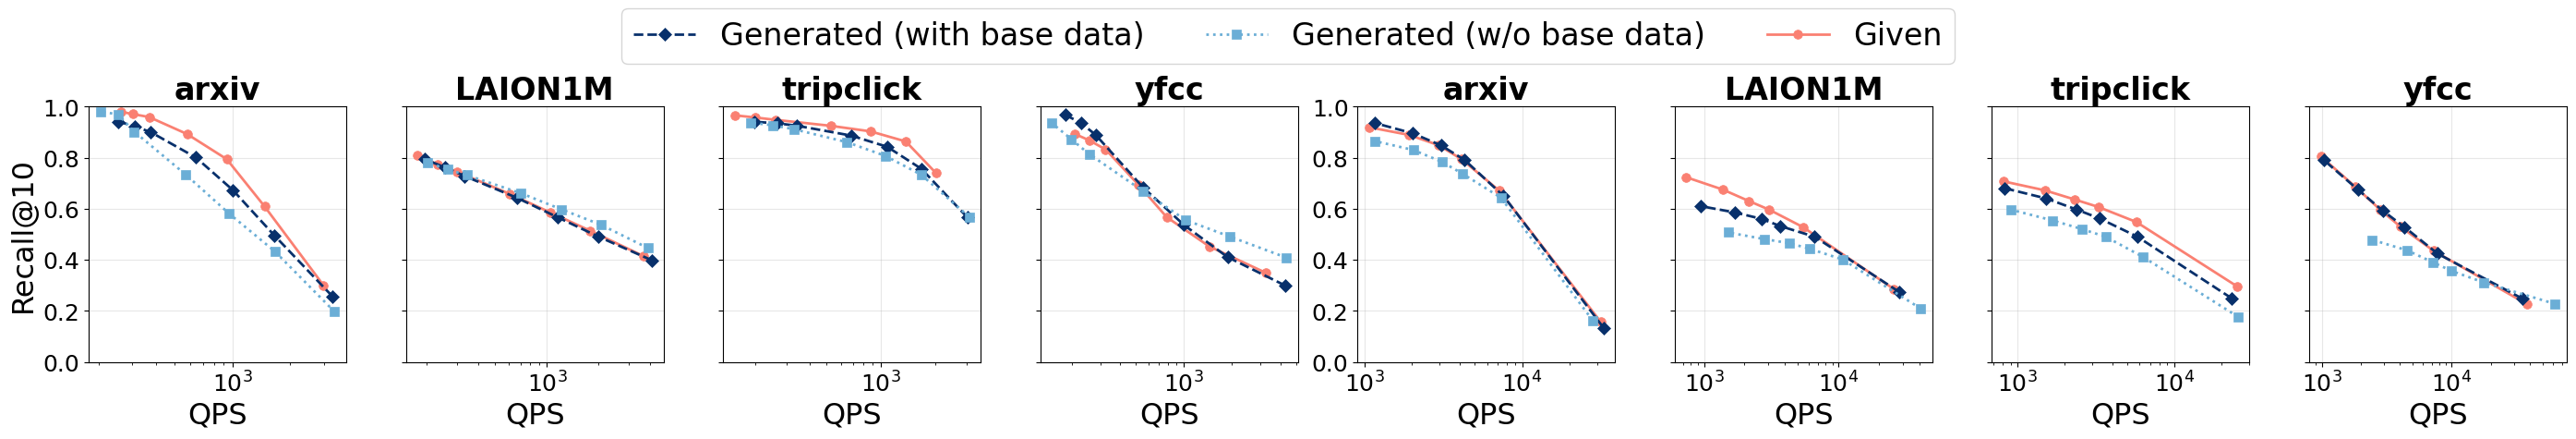

In [30]:
import pickle
import os
import matplotlib.pyplot as plt

# =================================================
# 0) 옵션: 스타일
# =================================================
MARKER_SIZE = 7
MARKER_EDGE_WIDTH = 0.5
LINE_WIDTH = 2

FS_TITLE   = 24
FS_LABEL   = 23
FS_TICK    = 18
FS_LEGEND  = 24
FS_METHOD  = 30   # "Post Filtering" / "RWalks"

# --------- layout tuning knobs ---------
GROUP_LABEL_Y   = -0.32   # Post Filtering / RWalks 세로 위치
SUBPLOT_WSPACE  = 0.05    # 서브플롯 가로 간격
SUBPLOT_HSPACE  = 0.00    # (1 row라 사실상 사용 안 됨)
# --------------------------------------

# =================================================
# 1) 데이터 로딩
# =================================================
with open("Post_Filtering_trade_off_all.pkl", "rb") as f:
    trade_off_pf = pickle.load(f)

with open("RWalks_trade_off_result_all.pkl", "rb") as f:
    trade_off_rwalks = pickle.load(f)

# =================================================
# 2) 데이터셋
# =================================================
datasets = ["arxiv", "LAION1M", "tripclick", "yfcc"]

# =================================================
# 3) 스타일
# =================================================
COLOR_MAP = {
    "generated": "#08306B",
    "generated_wo_payload": "#6BAED6",
    "given": "salmon",
}
LS_MAP = {
    "generated": "--",
    "generated_wo_payload": ":",
    "given": "-",
}
LABEL_MAP = {
    "generated": "Generated (with base data)",
    "generated_wo_payload": "Generated (w/o base data)",
    "given": "Given",
}
MARKER_MAP = {
    "generated": "D",
    "generated_wo_payload": "s",
    "given": "o",
}

# =================================================
# 4) helper
# =================================================
def classify_style(dataset_key: str, dataset: str) -> str:
    if dataset_key == dataset:
        return "given"
    if dataset_key == f"{dataset}_generated":
        return "generated"
    if dataset_key == f"{dataset}_generated_wo_payload":
        return "generated_wo_payload"
    if dataset_key.startswith(dataset) and dataset_key.endswith("_generated_wo_payload"):
        return "generated_wo_payload"
    if dataset_key.startswith(dataset) and dataset_key.endswith("_generated"):
        return "generated"
    if dataset_key.startswith(dataset):
        return "given"
    raise KeyError

def plot_one(ax, trade_off_dict, dataset):
    for dataset_key, stats_dict in trade_off_dict.items():
        if not dataset_key.startswith(dataset):
            continue

        style = classify_style(dataset_key, dataset)
        K_ns = sorted(stats_dict.keys())
        qps = [stats_dict[k]["qps"] for k in K_ns]
        recall = [stats_dict[k]["avg_recall"] for k in K_ns]

        ax.plot(
            qps,
            recall,
            marker=MARKER_MAP[style],
            markersize=MARKER_SIZE,
            linewidth=LINE_WIDTH,
            linestyle=LS_MAP[style],
            color=COLOR_MAP[style],
            label=LABEL_MAP[style],
            zorder=3 if style != "given" else 2,
            markeredgecolor=COLOR_MAP[style],
            markeredgewidth=MARKER_EDGE_WIDTH,
        )

# =================================================
# 5) Figure: 1 row × 8 columns
# =================================================
fig, axes = plt.subplots(1, 8, figsize=(28, 4.6), sharey=True)

# --- Left 4: Post Filtering ---
for j, dataset in enumerate(datasets):
    ax = axes[j]
    plot_one(ax, trade_off_pf, dataset)
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.set_title(dataset, fontsize=FS_TITLE, fontweight="bold")

# --- Right 4: RWalks ---
for j, dataset in enumerate(datasets):
    ax = axes[j + 4]
    plot_one(ax, trade_off_rwalks, dataset)
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.set_title(dataset, fontsize=FS_TITLE, fontweight="bold")

# =================================================
# 6) 축 라벨
# =================================================
for j in range(8):
    axes[j].set_xlabel("QPS", fontsize=FS_LABEL)

axes[0].set_ylabel("Recall@10", fontsize=FS_LABEL)
for idx in [0, 4]:
    axes[idx].tick_params(
        axis="y",
        which="both",
        left=True,
        labelleft=True
    )

# =================================================
# 7) 그룹 라벨 (중앙 아래, 위치 조정 가능)
# =================================================
# axes[1].text(
#     0.5, GROUP_LABEL_Y, "Post Filtering",
#     transform=axes[1].transAxes,
#     ha="center", va="top",
#     fontsize=FS_METHOD, fontweight="bold"
# )

# axes[5].text(
#     0.5, GROUP_LABEL_Y, "RWalks",
#     transform=axes[5].transAxes,
#     ha="center", va="top",
#     fontsize=FS_METHOD, fontweight="bold"
# )

# =================================================
# 8) Legend (상단 1 row)
# =================================================
handles, labels = axes[0].get_legend_handles_labels()
seen = set()
uh, ul = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        uh.append(h)
        ul.append(l)
        seen.add(l)

fig.legend(
    uh, ul,
    loc="upper center",
    ncol=3,
    fontsize=FS_LEGEND,
    frameon=True,
    bbox_to_anchor=(0.5, 1.08),
)

# =================================================
# 9) Layout & Save (간격 조정 가능)
# =================================================
plt.subplots_adjust(
    wspace=SUBPLOT_WSPACE,
    hspace=SUBPLOT_HSPACE
)

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
plt.savefig("fidelity_search_modi_wo.pdf", bbox_inches="tight", pad_inches=0.25)
plt.show()


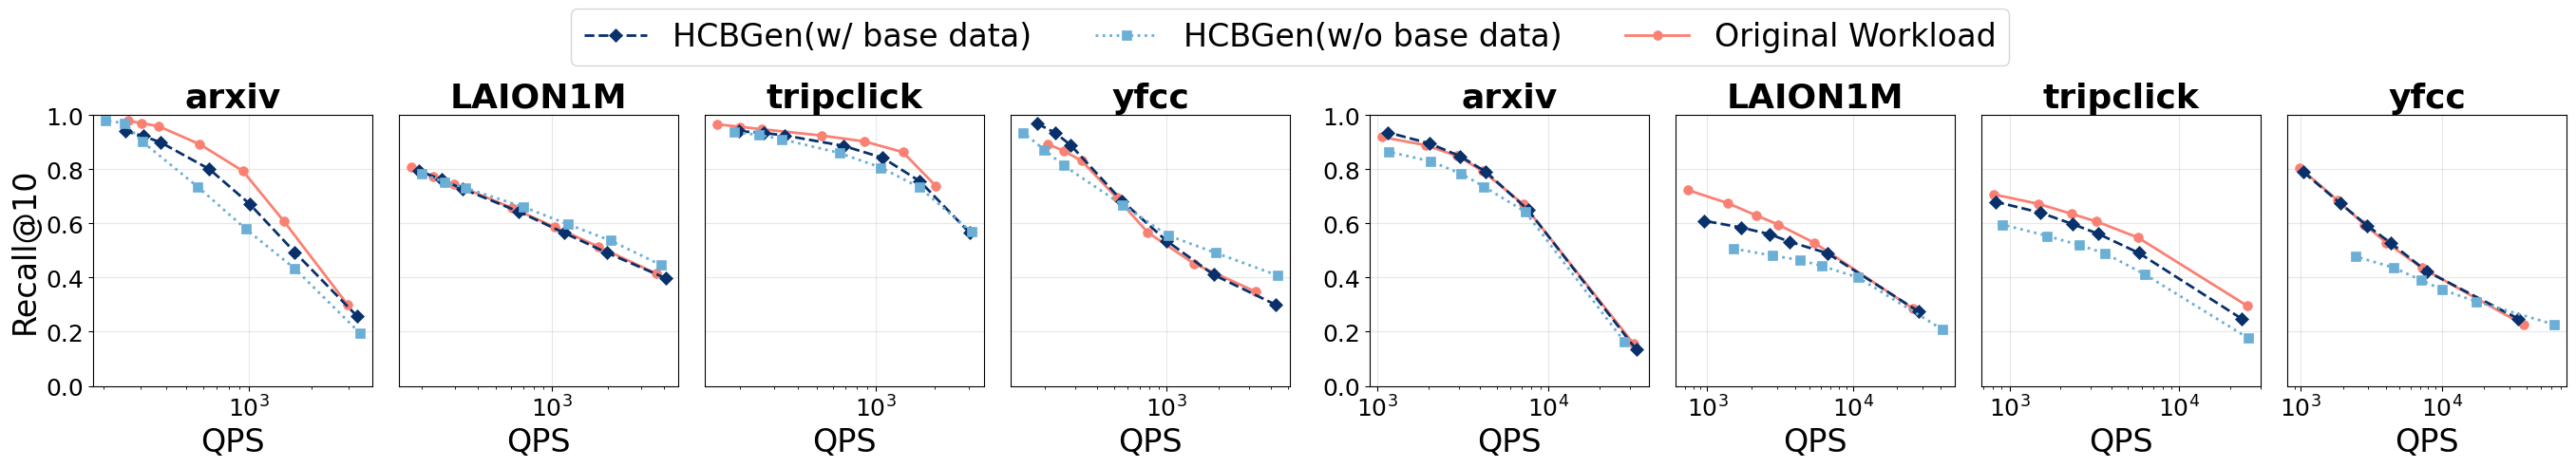

In [38]:
import pickle
import matplotlib.pyplot as plt

# =================================================
# 0) 옵션: 스타일
# =================================================
MARKER_SIZE = 7
MARKER_EDGE_WIDTH = 0.5
LINE_WIDTH = 2

FS_TITLE   = 26
FS_LABEL   = 24
FS_TICK    = 18
FS_LEGEND  = 24
FS_METHOD  = 30

# =================================================
# ✅ 개별 간격 튜닝 knobs
#   - gap[i] = i번째 축과 (i+1)번째 축 사이의 간격
#   - 길이는 7이어야 함 (8개 축 -> 사이 간격 7개)
# =================================================
GAPS = [0.01, 0.01, 0.01, 0.030, 0.01, 0.01, 0.01]
#              ^^^^^^^^^^^^^
#              Post(0-3) | RWalks(4-7) 사이를 더 벌리고 싶으면 gap[3] 키우면 됨

LEFT_MARGIN   = 0.05
RIGHT_MARGIN  = 0.02
BOTTOM        = 0.18
HEIGHT        = 0.62

# legend가 위에 있으니 top을 좀 낮춤
TOP_RESERVED  = 0.18   # 위쪽 여백(legend 영역)
# =================================================

# =================================================
# 1) 데이터 로딩
# =================================================
with open("Post_Filtering_trade_off_all.pkl", "rb") as f:
    trade_off_pf = pickle.load(f)

with open("RWalks_trade_off_result_all.pkl", "rb") as f:
    trade_off_rwalks = pickle.load(f)

# =================================================
# 2) 데이터셋
# =================================================
datasets = ["arxiv", "LAION1M", "tripclick", "yfcc"]

# =================================================
# 3) 스타일
# =================================================
COLOR_MAP = {
    "generated": "#08306B",
    "generated_wo_payload": "#6BAED6",
    "given": "salmon",
}
LS_MAP = {
    "generated": "--",
    "generated_wo_payload": ":",
    "given": "-",
}
LABEL_MAP = {
    "generated": "HCBGen(w/ base data)",
    "generated_wo_payload": "HCBGen(w/o base data)",
    "given": "Original Workload",
}
MARKER_MAP = {
    "generated": "D",
    "generated_wo_payload": "s",
    "given": "o",
}

# =================================================
# 4) helper
# =================================================
def classify_style(dataset_key: str, dataset: str) -> str:
    if dataset_key == dataset:
        return "given"
    if dataset_key == f"{dataset}_generated":
        return "generated"
    if dataset_key == f"{dataset}_generated_wo_payload":
        return "generated_wo_payload"
    if dataset_key.startswith(dataset) and dataset_key.endswith("_generated_wo_payload"):
        return "generated_wo_payload"
    if dataset_key.startswith(dataset) and dataset_key.endswith("_generated"):
        return "generated"
    if dataset_key.startswith(dataset):
        return "given"
    raise KeyError

def plot_one(ax, trade_off_dict, dataset):
    for dataset_key, stats_dict in trade_off_dict.items():
        if not dataset_key.startswith(dataset):
            continue

        style = classify_style(dataset_key, dataset)
        K_ns = sorted(stats_dict.keys())
        qps = [stats_dict[k]["qps"] for k in K_ns]
        recall = [stats_dict[k]["avg_recall"] for k in K_ns]

        ax.plot(
            qps,
            recall,
            marker=MARKER_MAP[style],
            markersize=MARKER_SIZE,
            linewidth=LINE_WIDTH,
            linestyle=LS_MAP[style],
            color=COLOR_MAP[style],
            label=LABEL_MAP[style],
            zorder=3 if style != "given" else 2,
            markeredgecolor=COLOR_MAP[style],
            markeredgewidth=MARKER_EDGE_WIDTH,
        )

# =================================================
# 5) Figure + 개별 배치(핵심)
# =================================================
fig = plt.figure(figsize=(28, 4.6))

# 축 8개 만들기
axes = [fig.add_axes([0, 0, 0, 0]) for _ in range(8)]

# 각 축 width 계산: 전체 usable width에서 gap들을 빼고 8등분
total_gap = sum(GAPS)
usable_width = 1.0 - LEFT_MARGIN - RIGHT_MARGIN - total_gap
ax_w = usable_width / 8.0

# left 위치 누적
left = LEFT_MARGIN
for i in range(8):
    axes[i].set_position([left, BOTTOM, ax_w, HEIGHT])
    if i < 7:
        left += ax_w + GAPS[i]

# =================================================
# 6) Plot
# =================================================
# Left 4: Post Filtering
for j, dataset in enumerate(datasets):
    ax = axes[j]
    plot_one(ax, trade_off_pf, dataset)
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.set_title(dataset, fontsize=FS_TITLE, fontweight="bold")

# Right 4: RWalks
for j, dataset in enumerate(datasets):
    ax = axes[j + 4]
    plot_one(ax, trade_off_rwalks, dataset)
    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=FS_TICK)
    ax.set_title(dataset, fontsize=FS_TITLE, fontweight="bold")

# =================================================
# 7) 축 라벨 + ytick 0/4만
# =================================================
for j in range(8):
    axes[j].set_xlabel("QPS", fontsize=FS_LABEL)

axes[0].set_ylabel("Recall@10", fontsize=FS_LABEL)

for idx in [0, 4]:
    axes[idx].tick_params(axis="y", which="both", left=True, labelleft=True)

# 나머지 축은 y tick label 숨김(sharey 스타일 유지)
for idx in [1, 2, 3, 5, 6, 7]:
    axes[idx].tick_params(axis="y", which="both", left=False, labelleft=False)

# =================================================
# 8) Legend (상단 1 row)
# =================================================
handles, labels = axes[0].get_legend_handles_labels()
seen = set()
uh, ul = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        uh.append(h)
        ul.append(l)
        seen.add(l)

fig.legend(
    uh, ul,
    loc="upper center",
    ncol=3,
    fontsize=FS_LEGEND,
    frameon=True,
    bbox_to_anchor=(0.5, 1.08),
)

# =================================================
# 9) Save
# =================================================
plt.savefig("fidelity_search.pdf", bbox_inches="tight", pad_inches=0.25)
plt.show()
